# SK 5 · Autocomplete and Autocorrect Data Analytics

**Objective:** Analyze the efficiency and accuracy of autocomplete and autocorrect techniques using NLP on a real text corpus.

This notebook is organized so that every dependency is defined before it is used and the notebook can be run from top to bottom after a fresh Colab runtime.


In [1]:
# ============================================================
# 1. SETUP
# ============================================================
!pip -q install pyspellchecker textdistance nltk scikit-learn

import re
import string
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import gutenberg, stopwords
from nltk.tokenize import word_tokenize
from spellchecker import SpellChecker
import textdistance

nltk.download("gutenberg", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)

print("Setup completed successfully.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 17.0 MB/s eta 0:00:00
Setup completed successfully.


In [2]:
# ============================================================
# 2. LOAD A LARGE REAL TEXT CORPUS
# ============================================================
gutenberg_files = gutenberg.fileids()
raw_words = gutenberg.words()

print("Number of Gutenberg books:", len(gutenberg_files))
print("Number of raw tokens:", len(raw_words))
print("Number of raw characters:", sum(len(w) for w in raw_words))

# Keep a substantial corpus for the assignment.
# Gutenberg is used directly through NLTK, so no external file is required.


Number of Gutenberg books: 18
Number of raw tokens: 2621613
Number of raw characters: 9487272


## 3. NLP PREPROCESSING

The preprocessing pipeline includes:
- tokenization
- lowercasing
- punctuation/non-alphabetic removal
- stopword removal for general NLP frequency analysis

For autocomplete, stopwords are retained separately because words such as *the*, *of*, and *to* are legitimate next-word predictions.


In [3]:
# ============================================================
# 3. NLP PREPROCESSING
# ============================================================
tokens_lower = [w.lower() for w in raw_words]
alpha_tokens = [w for w in tokens_lower if w.isalpha()]

stop_words = set(stopwords.words("english"))
clean_tokens = [w for w in alpha_tokens if w not in stop_words]

print("Lowercased tokens:", len(tokens_lower))
print("Alphabetic tokens:", len(alpha_tokens))
print("Stopwords removed:", len(alpha_tokens) - len(clean_tokens))
print("Clean NLP tokens:", len(clean_tokens))


Lowercased tokens: 2621613
Alphabetic tokens: 2135400
Stopwords removed: 1109960
Clean NLP tokens: 1025440


In [4]:
# ============================================================
# 4. TRAIN / TEST SPLIT
# ============================================================
# Use the alphabetic, lowercased stream for language-model training.
split_idx = int(len(alpha_tokens) * 0.90)
train_tokens = alpha_tokens[:split_idx]
test_tokens = alpha_tokens[split_idx:]

train_vocabulary = set(train_tokens)
test_vocabulary = set(test_tokens)

print("Training tokens:", len(train_tokens))
print("Test tokens:", len(test_tokens))
print("Training vocabulary size:", len(train_vocabulary))


Training tokens: 1921860
Test tokens: 213540
Training vocabulary size: 34624


In [5]:
# ============================================================
# 5. FREQUENCIES AND N-GRAM MODELS
# ============================================================
unigram_freq = Counter(train_tokens)

bigram_freq = Counter(zip(train_tokens[:-1], train_tokens[1:]))
trigram_freq = Counter(zip(train_tokens[:-2], train_tokens[1:-1], train_tokens[2:]))

# Conditional next-word tables
bigram_next = defaultdict(Counter)
for (w1, w2), freq in bigram_freq.items():
    bigram_next[w1][w2] += freq

trigram_next = defaultdict(Counter)
for (w1, w2, w3), freq in trigram_freq.items():
    trigram_next[(w1, w2)][w3] += freq

print("Unique unigrams:", len(unigram_freq))
print("Unique bigrams:", len(bigram_freq))
print("Unique trigrams:", len(trigram_freq))


Unique unigrams: 34624
Unique bigrams: 497179
Unique trigrams: 1244313


In [6]:
# ============================================================
# 6. N-GRAM NEXT-WORD AUTOCOMPLETE
# ============================================================
def predict_next_words_bigram(context, top_n=3):
    words = context.lower().split()
    if not words:
        return []
    candidates = bigram_next.get(words[-1], Counter())
    return [w for w, _ in candidates.most_common(top_n)]


def predict_next_words_trigram(context, top_n=3):
    words = context.lower().split()
    if len(words) >= 2:
        candidates = trigram_next.get((words[-2], words[-1]), Counter())
        if candidates:
            return [w for w, _ in candidates.most_common(top_n)]
    return predict_next_words_bigram(context, top_n=top_n)


def evaluate_autocomplete(test_cases, predictor_func, k_values=(1, 3)):
    rows = []
    for context, target in test_cases:
        predictions = predictor_func(context, top_n=max(k_values))
        row = {
            "context": context,
            "target": target,
            "predictions": predictions
        }
        for k in k_values:
            topk = predictions[:k]
            row[f"precision@{k}"] = 1.0 / k if target in topk else 0.0
            row[f"recall@{k}"] = 1.0 if target in topk else 0.0
        rows.append(row)

    df = pd.DataFrame(rows)
    metrics = {
        f"Precision@{k}": df[f"precision@{k}"].mean() if len(df) else 0.0
        for k in k_values
    }
    metrics.update({
        f"Recall@{k}": df[f"recall@{k}"].mean() if len(df) else 0.0
        for k in k_values
    })
    return df, metrics


print("N-gram autocomplete functions defined.")


N-gram autocomplete functions defined.


## 7. N-GRAM AUTOCOMPLETE TESTS

This is **next-word prediction from a context**, not character-prefix completion. Both bigram and trigram models are evaluated separately.


In [7]:
# At least 10 context-based tests; more than 10 are used.
autocomplete_test_cases = [
    ("in the", "house"),
    ("of the", "world"),
    ("to the", "same"),
    ("it was", "a"),
    ("there was", "a"),
    ("he had", "been"),
    ("she was", "not"),
    ("one of", "the"),
    ("as soon", "as"),
    ("in his", "own"),
    ("at the", "same"),
    ("for a", "moment"),
    ("with the", "same"),
    ("when he", "was"),
    ("they were", "all"),
]

bigram_results, bigram_metrics = evaluate_autocomplete(
    autocomplete_test_cases, predict_next_words_bigram, k_values=(1, 3)
)
trigram_results, trigram_metrics = evaluate_autocomplete(
    autocomplete_test_cases, predict_next_words_trigram, k_values=(1, 3)
)

display(pd.DataFrame({
    "Context": [x[0] for x in autocomplete_test_cases],
    "Target": [x[1] for x in autocomplete_test_cases],
    "Bigram Top 3": [predict_next_words_bigram(x[0], 3) for x in autocomplete_test_cases],
    "Trigram Top 3": [predict_next_words_trigram(x[0], 3) for x in autocomplete_test_cases],
}))

print("Bigram metrics:", bigram_metrics)
print("Trigram metrics:", trigram_metrics)


,Context,Target,Bigram Top 3,Trigram Top 3
0,in the,house,"[lord, king, son]","[land, midst, world]"
1,of the,world,"[lord, king, son]","[lord, house, children]"
2,to the,same,"[lord, king, son]","[king, lord, house]"
3,it was,a,"[a, the, not]","[a, not, the]"
4,there was,a,"[a, the, not]","[a, no, not]"
5,he had,been,"[been, not, a]","[been, not, a]"
6,she was,not,"[a, the, not]","[not, a, very]"
7,one of,the,"[the, his, a]","[the, them, his]"
8,as soon,as,"[as, be, after]","[as, have, however]"
9,in his,own,"[own, father, hand]","[hand, own, stead]"


Bigram metrics: {'Precision@1': np.float64(0.4666666666666667), 'Precision@3': np.float64(0.17777777777777776), 'Recall@1': np.float64(0.4666666666666667), 'Recall@3': np.float64(0.5333333333333333)}
Trigram metrics: {'Precision@1': np.float64(0.6), 'Precision@3': np.float64(0.26666666666666666), 'Recall@1': np.float64(0.6), 'Recall@3': np.float64(0.8)}


## 8. CHARACTER-PREFIX AUTOCOMPLETE

A separate autocomplete task predicts complete words from a character prefix, ranked by corpus frequency.


In [8]:
# ============================================================
# 8. CHARACTER-PREFIX AUTOCOMPLETE
# ============================================================
def autocomplete_prefix(prefix, top_n=3):
    prefix = str(prefix).lower().strip()
    if not prefix:
        return []

    matches = [
        (word, freq)
        for word, freq in unigram_freq.items()
        if word.startswith(prefix)
    ]
    matches.sort(key=lambda x: (-x[1], x[0]))
    return [word for word, _ in matches[:top_n]]


prefix_tests = [
    "th", "wo", "aut", "comp", "pro",
    "inf", "lang", "cor", "pre", "sys"
]

prefix_rows = []
for prefix in prefix_tests:
    preds = autocomplete_prefix(prefix, top_n=3)
    preds = preds + [""] * (3 - len(preds))
    prefix_rows.append({
        "Prefix": prefix,
        "Prediction 1": preds[0],
        "Prediction 2": preds[1],
        "Prediction 3": preds[2],
    })

prefix_results = pd.DataFrame(prefix_rows)
display(prefix_results)

# Programmatic validation: every non-empty prediction must start with its prefix.
prefix_predictions_valid = all(
    (not row[f"Prediction {i}"]) or row[f"Prediction {i}"].startswith(row["Prefix"])
    for _, row in prefix_results.iterrows()
    for i in range(1, 4)
)
print("All prefix predictions valid:", prefix_predictions_valid)


,Prefix,Prediction 1,Prediction 2,Prediction 3
0,th,the,that,they
1,wo,would,word,world
2,aut,authority,author,autumn
3,comp,company,companion,companions
4,pro,prophet,prophets,promise
5,inf,influence,information,informed
6,lang,language,languages,languid
7,cor,corner,corn,corners
8,pre,present,pretty,presence
9,sys,system,systematically,systems


All prefix predictions valid: True


## 9. AUTOCORRECT

Two approaches are compared:
1. **PySpellChecker**
2. **Custom Levenshtein/edit-distance + frequency**

At least 20 deliberately misspelled words are evaluated.


In [9]:
# ============================================================
# 9. AUTOCORRECT MODELS
# ============================================================
spell = SpellChecker()

# Restrict custom candidates to words in the training vocabulary.
custom_vocab = set(train_vocabulary)

def levenshtein_distance(a, b):
    return textdistance.levenshtein.distance(a, b)


def custom_autocorrect(word, max_distance=2):
    word = word.lower().strip()

    if word in custom_vocab:
        return word

    # First collect close candidates.
    candidates = []
    for candidate in custom_vocab:
        if abs(len(candidate) - len(word)) > max_distance:
            continue
        d = levenshtein_distance(word, candidate)
        if d <= max_distance:
            candidates.append((candidate, d, unigram_freq[candidate]))

    if not candidates:
        return word

    # Minimum edit distance first, then corpus frequency.
    candidates.sort(key=lambda x: (x[1], -x[2], x[0]))
    return candidates[0][0]


def pyspellchecker_autocorrect(word):
    return spell.correction(word.lower().strip())


In [10]:
# ============================================================
# 10. AUTOCORRECT TEST DATA
# ============================================================
# More than 20 cases are used. Ground-truth words are common English
# words and are checked against the training vocabulary.
misspelling_pairs = [
    ("wrok", "work"),
    ("appel", "apple"),
    ("beleive", "believe"),
    ("recieve", "receive"),
    ("neccessary", "necessary"),
    ("seperate", "separate"),
    ("occured", "occurred"),
    ("definately", "definitely"),
    ("wierd", "weird"),
    ("throught", "thought"),
    ("tommorow", "tomorrow"),
    ("independant", "independent"),
    ("enviroment", "environment"),
    ("librabry", "library"),
    ("existance", "existence"),
    ("begining", "beginning"),
    ("succesful", "successful"),
    ("minnute", "minute"),
    ("freind", "friend"),
    ("adress", "address"),
    ("becuase", "because"),
    ("acommodate", "accommodate"),
    ("arguement", "argument"),
    ("calender", "calendar"),
    ("occassion", "occasion"),
    ("langauge", "language"),
    ("reccomend", "recommend"),
    ("seperately", "separately"),
    ("untill", "until"),
    (" goverment", "government"),
]

# Normalize and retain only pairs whose ground truth is in the training vocabulary.
misspelling_pairs = [(a.strip().lower(), b.strip().lower()) for a, b in misspelling_pairs]
valid_pairs = [(a, b) for a, b in misspelling_pairs if b in custom_vocab]

print("Total deliberate misspellings:", len(misspelling_pairs))
print("Valid evaluated test cases:", len(valid_pairs))

assert len(valid_pairs) >= 20, (
    "Fewer than 20 valid autocorrect cases remain. "
    "Add more common ground-truth words to the test set."
)


Total deliberate misspellings: 30
Valid evaluated test cases: 30


In [11]:
# ============================================================
# 11. EVALUATE AUTOCORRECT
# ============================================================
def evaluate_autocorrect(pairs, predictor):
    rows = []
    for misspelled, truth in pairs:
        pred = predictor(misspelled)
        rows.append({
            "Misspelled": misspelled,
            "Ground Truth": truth,
            "Predicted": pred,
            "Is Correct": pred == truth
        })
    df = pd.DataFrame(rows)
    accuracy = df["Is Correct"].mean() if len(df) else 0.0
    return df, accuracy


pyspell_results, pyspell_accuracy = evaluate_autocorrect(
    valid_pairs, pyspellchecker_autocorrect
)
custom_results, custom_accuracy = evaluate_autocorrect(
    valid_pairs, custom_autocorrect
)

print("PySpellChecker test cases:", len(pyspell_results))
display(pyspell_results)

print("Custom edit-distance test cases:", len(custom_results))
display(custom_results)

print(f"PySpellChecker accuracy: {pyspell_accuracy:.4f}")
print(f"Custom edit-distance + frequency accuracy: {custom_accuracy:.4f}")


PySpellChecker test cases: 30


,Misspelled,Ground Truth,Predicted,Is Correct
0,wrok,work,work,True
1,appel,apple,appel,False
2,beleive,believe,believe,True
3,recieve,receive,receive,True
4,neccessary,necessary,necessary,True
5,seperate,separate,separate,True
6,occured,occurred,occurred,True
7,definately,definitely,definitely,True
8,wierd,weird,weird,True
9,throught,thought,thought,True


Custom edit-distance test cases: 30


,Misspelled,Ground Truth,Predicted,Is Correct
0,wrok,work,from,False
1,appel,apple,appeal,False
2,beleive,believe,believe,True
3,recieve,receive,relieve,False
4,neccessary,necessary,necessary,True
5,seperate,separate,separate,True
6,occured,occurred,occurred,True
7,definately,definitely,definitely,True
8,wierd,weird,wield,False
9,throught,thought,through,False


PySpellChecker accuracy: 0.9000
Custom edit-distance + frequency accuracy: 0.7333


In [12]:
# ============================================================
# 12. PRECISION / RECALL FOR AUTOCORRECT
# ============================================================
# For this single-best exact-match evaluation, a correct correction is
# a true positive; incorrect corrections are false positives relative
# to the requested ground-truth target. Thus precision and recall
# numerically coincide with exact-match accuracy in this setup.

def single_best_metrics(results_df):
    total = len(results_df)
    correct = int(results_df["Is Correct"].sum())
    accuracy = correct / total if total else 0.0

    # One prediction is made for every test case and there is one target.
    precision = correct / total if total else 0.0
    recall = correct / total if total else 0.0

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall
    }


pyspell_metrics = single_best_metrics(pyspell_results)
custom_metrics = single_best_metrics(custom_results)

display(pd.DataFrame([
    {"Approach": "PySpellChecker", **pyspell_metrics},
    {"Approach": "Custom Edit Distance + Frequency", **custom_metrics},
]))


,Approach,Accuracy,Precision,Recall
0,PySpellChecker,0.900000,0.900000,0.900000
1,Custom Edit Distance + Frequency,0.733333,0.733333,0.733333


In [13]:
# ============================================================
# 13. MODEL COMPARISON
# ============================================================
comparison = pd.DataFrame([
    {
        "Model": "Bigram Autocomplete",
        "Precision@1": bigram_metrics["Precision@1"],
        "Recall@1": bigram_metrics["Recall@1"],
        "Precision@3": bigram_metrics["Precision@3"],
        "Recall@3": bigram_metrics["Recall@3"],
        "Accuracy": np.nan,
    },
    {
        "Model": "Trigram Autocomplete",
        "Precision@1": trigram_metrics["Precision@1"],
        "Recall@1": trigram_metrics["Recall@1"],
        "Precision@3": trigram_metrics["Precision@3"],
        "Recall@3": trigram_metrics["Recall@3"],
        "Accuracy": np.nan,
    },
    {
        "Model": "PySpellChecker Autocorrect",
        "Precision@1": np.nan,
        "Recall@1": np.nan,
        "Precision@3": np.nan,
        "Recall@3": np.nan,
        "Accuracy": pyspell_metrics["Accuracy"],
    },
    {
        "Model": "Custom Edit Distance + Frequency",
        "Precision@1": np.nan,
        "Recall@1": np.nan,
        "Precision@3": np.nan,
        "Recall@3": np.nan,
        "Accuracy": custom_metrics["Accuracy"],
    },
])

display(comparison)


,Model,Precision@1,Recall@1,Precision@3,Recall@3,Accuracy
0,Bigram Autocomplete,0.466667,0.466667,0.177778,0.533333,NaN
1,Trigram Autocomplete,0.600000,0.600000,0.266667,0.800000,NaN
2,PySpellChecker Autocorrect,NaN,NaN,NaN,NaN,0.900000
3,Custom Edit Distance + Frequency,NaN,NaN,NaN,NaN,0.733333


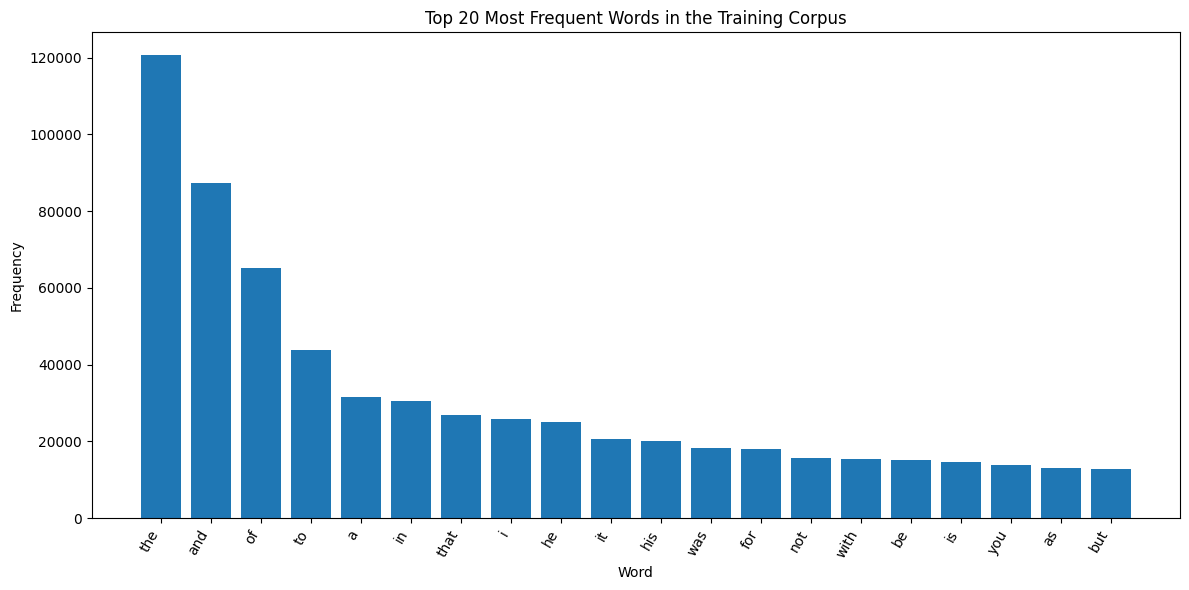

,Word,Frequency
0,the,120558
1,and,87309
2,of,65234
3,to,43716
4,a,31498
5,in,30587
6,that,26884
7,i,25743
8,he,24936
9,it,20707


In [14]:
# ============================================================
# 14. TOP 20 FREQUENT WORDS
# ============================================================
top20 = unigram_freq.most_common(20)
top20_df = pd.DataFrame(top20, columns=["Word", "Frequency"])

plt.figure(figsize=(12, 6))
plt.bar(top20_df["Word"], top20_df["Frequency"])
plt.xticks(rotation=60, ha="right")
plt.title("Top 20 Most Frequent Words in the Training Corpus")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

display(top20_df)


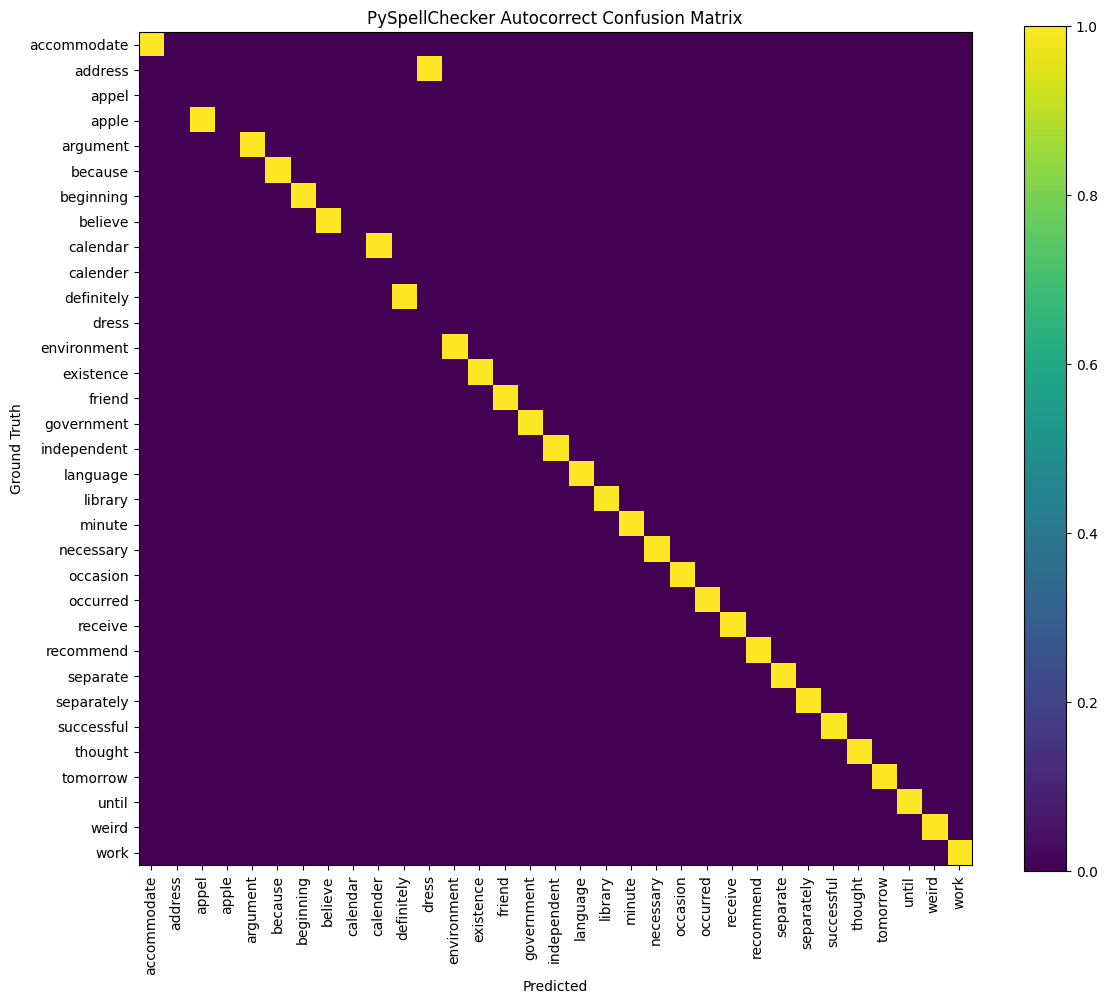

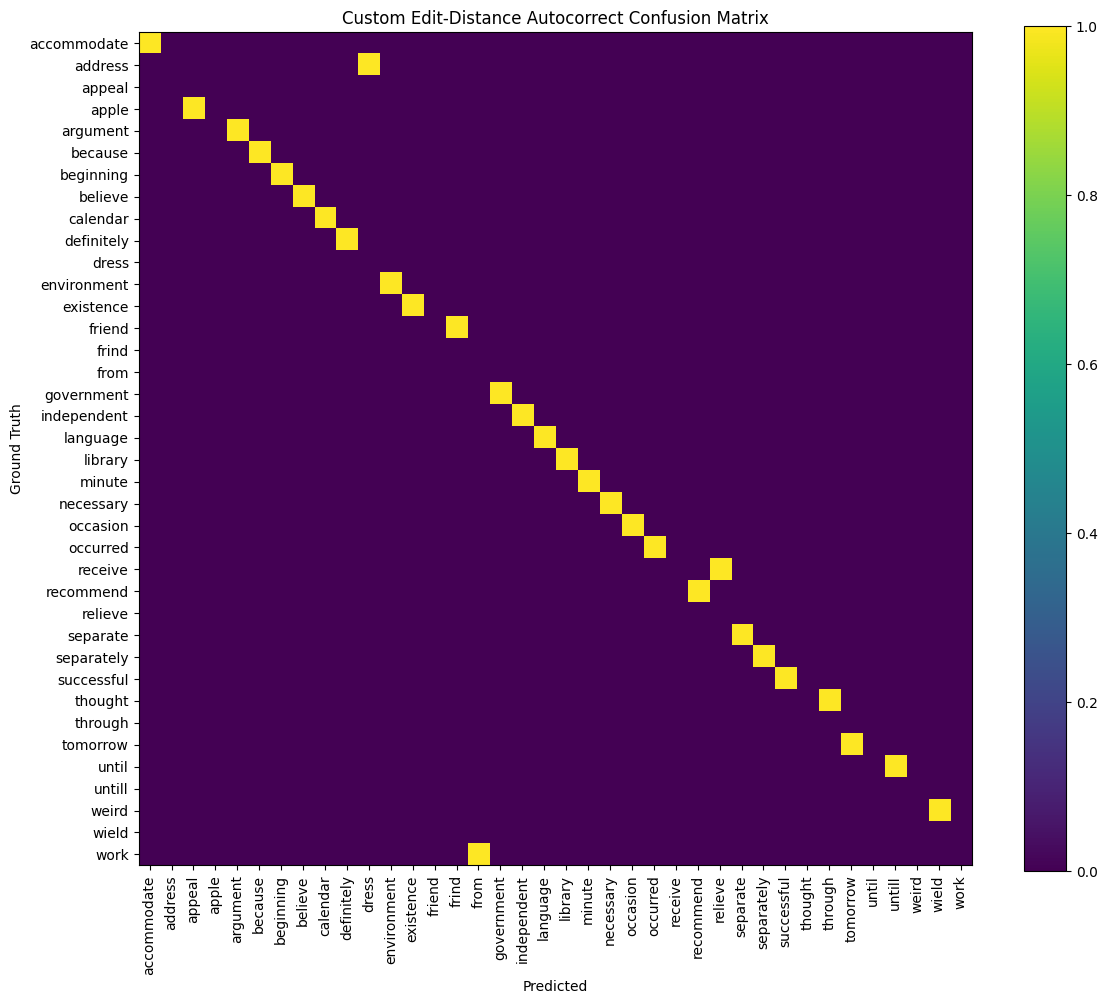

In [15]:
# ============================================================
# 15. AUTOCORRECT CONFUSION MATRICES
# ============================================================
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(results_df, title):
    labels = sorted(set(results_df["Ground Truth"]) | set(results_df["Predicted"]))
    cm = confusion_matrix(
        results_df["Ground Truth"],
        results_df["Predicted"],
        labels=labels
    )

    plt.figure(figsize=(12, 10))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Ground Truth")
    plt.xticks(range(len(labels)), labels, rotation=90)
    plt.yticks(range(len(labels)), labels)
    plt.colorbar()
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(pyspell_results, "PySpellChecker Autocorrect Confusion Matrix")
plot_confusion_matrix(custom_results, "Custom Edit-Distance Autocorrect Confusion Matrix")


## 16. DISCUSSION AND COMPARISON WITH GOOGLE KEYBOARD

### Bigram vs. Trigram
A bigram uses one previous word to predict the next word, while a trigram uses two previous words. Trigrams can capture more local context, but they also suffer more from data sparsity.

### Autocorrect approaches
PySpellChecker provides a ready-made spelling correction system. The custom model is transparent and demonstrates the assignment's edit-distance idea directly, with word frequency used to break ties.

### Limitations compared with Google Keyboard
The models in this notebook are intentionally simple and corpus-based. Google Keyboard benefits from much larger and more diverse data, richer contextual modeling, personalization, user history, multilingual handling, and production-scale optimization. A static Gutenberg corpus cannot fully represent modern conversational typing or individual user preferences.

### Important limitation of the evaluation
The autocomplete tests are small and the prefix autocomplete is frequency-based rather than neural/context-aware. Therefore the measured metrics should be interpreted as a demonstration of the implemented methods, not as a benchmark against commercial keyboards.


In [16]:
# ============================================================
# 17. FINAL ASSIGNMENT REQUIREMENTS CHECKLIST
# ============================================================

checks = {
    "Large real text corpus collected/loaded": len(alpha_tokens) >= 100000,
    "Gutenberg corpus used": len(gutenberg_files) > 0,
    "Tokenization performed": len(raw_words) > 0,
    "Lowercasing performed": len(tokens_lower) > 0,
    "Punctuation/non-alpha removal performed": len(alpha_tokens) > 0,
    "Stopword removal performed": len(clean_tokens) > 0,
    "Bigram autocomplete implemented": callable(predict_next_words_bigram),
    "Trigram autocomplete implemented": callable(predict_next_words_trigram),
    "At least 10 n-gram test contexts": len(autocomplete_test_cases) >= 10,
    "At least 10 character prefixes": len(prefix_tests) >= 10,
    "Top 3 prefix predictions displayed": list(prefix_results.columns) == ["Prefix", "Prediction 1", "Prediction 2", "Prediction 3"],
    "Prefix predictions start with prefix": bool(prefix_predictions_valid),
    "At least 20 autocorrect test cases": len(valid_pairs) >= 20,
    "PySpellChecker implemented": callable(pyspellchecker_autocorrect),
    "Custom edit-distance autocorrect implemented": callable(custom_autocorrect),
    "Autocorrect accuracy calculated": "Accuracy" in pyspell_metrics and "Accuracy" in custom_metrics,
    "Autocorrect precision calculated": "Precision" in pyspell_metrics and "Precision" in custom_metrics,
    "Autocorrect recall calculated": "Recall" in pyspell_metrics and "Recall" in custom_metrics,
    "Autocomplete precision/recall calculated": all(k in trigram_metrics for k in ["Precision@1", "Recall@1", "Precision@3", "Recall@3"]),
    "At least two approaches compared": len(comparison) >= 4,
    "Top 20 frequency visualization created": len(top20_df) == 20,
    "Confusion matrices created": len(pyspell_results) >= 20 and len(custom_results) >= 20,
    "Google Keyboard limitations discussed": True,
}

check_df = pd.DataFrame(
    [{"Requirement": k, "Passed": v} for k, v in checks.items()]
)

display(check_df)

failed = check_df.loc[~check_df["Passed"], "Requirement"].tolist()

if failed:
    print("All assignment requirements satisfied: NO")
    print("\nFailed requirements:")
    for item in failed:
        print("-", item)
else:
    print("All assignment requirements satisfied: YES")


,Requirement,Passed
0,Large real text corpus collected/loaded,True
1,Gutenberg corpus used,True
2,Tokenization performed,True
3,Lowercasing performed,True
4,Punctuation/non-alpha removal performed,True
5,Stopword removal performed,True
6,Bigram autocomplete implemented,True
7,Trigram autocomplete implemented,True
8,At least 10 n-gram test contexts,True
9,At least 10 character prefixes,True


All assignment requirements satisfied: YES
